# Домашнє завдання до модуля «Класифікація зображень»
## Компоненти моделі
### Клас перетворення картинок у датасетах
Розподіляє дані на тренувальні та валідаційні та додає перетворювачі даних картинок длч подальшого перетворення у тензори з подальшою їх нормалізацією. В тренувальному наборі ми збільшуємо кількість експериментів за допомогою:

- Випадковим вирізанням ділянок
- Випадковим горизнтальним поворотом

In [1]:
import optuna
import torch
from torchvision import transforms
from dataclasses import dataclass

@dataclass
class DataTransformers:
    train: transforms.Compose = transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225]),
    ])
    val: transforms.Compose = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225]),
    ])

### Клас, що оформляє датасет
Створює тренувальний та валідаційний датасети в обʼєкти `datasets.ImageFolder` з додаванням до кожного відповідного трансформера даних.

In [2]:
from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import torch
from torchvision import datasets


@dataclass(frozen=True)
class SplitPaths:
    train_dir: Path
    val_dir: Path


class DataSet:
    def __init__(self, folder_path: Path):
        self.data_transformers = DataTransformers()

        folder_path = Path(folder_path)
        splits = self._resolve_splits(folder_path)

        self.train_dataset = datasets.ImageFolder(
            splits.train_dir, transform=self.data_transformers.train
        )
        self.val_dataset = datasets.ImageFolder(
            splits.val_dir, transform=self.data_transformers.val
        )

        self.train = torch.utils.data.DataLoader(
            self.train_dataset,
            batch_size=32,
            shuffle=True,
            pin_memory=torch.cuda.is_available() or torch.backends.mps.is_available(),
        )
        self.val = torch.utils.data.DataLoader(
            self.val_dataset,
            batch_size=32,
            shuffle=False,
            pin_memory=torch.cuda.is_available() or torch.backends.mps.is_available(),
        )

        self.classes_amount = len(self.train_dataset.classes)

    @staticmethod
    def _looks_like_imagefolder_root(p: Path) -> bool:
        """True if `p` contains class subfolders (at least 2), typical for ImageFolder."""
        if not p.exists() or not p.is_dir():
            return False
        class_dirs = [d for d in p.iterdir() if d.is_dir() and not d.name.startswith(".")]
        return len(class_dirs) >= 2

    @classmethod
    def _find_candidate_dir(cls, base: Path, names: set[str]) -> Optional[Path]:
        """
        Search for a directory named in `names` such that it is an ImageFolder root.
        Also handles nested layouts like seg_train/seg_train/<classes>.
        """
        # 1) direct children first (fast path)
        for n in names:
            p = base / n
            if cls._looks_like_imagefolder_root(p):
                return p
            # handle nested common kaggle pattern: seg_train/seg_train
            nested = p / n
            if cls._looks_like_imagefolder_root(nested):
                return nested

        # 2) recursive search (robust)
        for p in base.rglob("*"):
            if p.is_dir() and p.name in names:
                if cls._looks_like_imagefolder_root(p):
                    return p
                nested = p / p.name
                if cls._looks_like_imagefolder_root(nested):
                    return nested

        return None

    @classmethod
    def _resolve_splits(cls, folder_path: Path) -> SplitPaths:
        train_names = {"train", "seg_train"}
        val_names = {"val", "valid", "validation", "seg_val", "seg_valid"}
        test_names = {"test", "seg_test"}

        train_dir = cls._find_candidate_dir(folder_path, train_names)
        if train_dir is None:
            raise FileNotFoundError(
                "Не знайдено папку train/seg_train у структурі датасету. "
                f"Перевірте, що шлях правильний: {folder_path}"
            )

        val_dir = cls._find_candidate_dir(folder_path, val_names)
        if val_dir is None:
            # fallback: use test as validation if val is absent
            val_dir = cls._find_candidate_dir(folder_path, test_names)

        if val_dir is None:
            raise FileNotFoundError(
                "Не знайдено папку val/validation або test/seg_test у структурі датасету. "
                "Або додайте val-спліт, або зробіть split з train."
            )

        return SplitPaths(train_dir=train_dir, val_dir=val_dir)

### Сама модель
Клас, котрий імплементує саму модель класифікацію. Наша модель має наступну архітектуру:

- Як перший шар ми використовуємо претреновану згорткову нейромережу *ResNET 50* з конфігурабельними параметрами, щоб потім тюнити через бібліотеку **optuna**
- Вихідний шар мережі візьмемо звичайну лінійну регресію
- Параметри шару також конфігурабельні

In [3]:
from matplotlib import pyplot as plt
from tempfile import TemporaryDirectory
from torch import nn, optim
import torchvision


import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix


class SNNModel:
    def __init__(
        self,
        folder_path: Path,
        requires_grad: bool,
        lr: float = 1e-5,
        step_size: int = 7,
        gamma: float = 0.1,
        epochs: int = 5,
        batch_size: int | None = None,
        num_workers: int | None = None,
        tune_strategy: str = "all",          # "head_only" | "last_block" | "all"
        lr_head: float | None = None,
        lr_backbone: float | None = None,
        optimizer_name: str = "adamw",       # "adamw" | "adam" | "sgd"
        weight_decay: float = 0.0,
        scheduler_name: str = "step",        # "none" | "step" | "plateau" | "cosine"
        plateau_patience: int = 2,
        plateau_factor: float = 0.5,
        resnet18_weights: str = "IMAGENET1K_V1",
    ):
        self.epochs = epochs

        # було:
        # self.data_set = DataSet(folder_path)
        # стало: пробуємо прокинути batch_size/num_workers, але не ламаємо старий DataSet,
        # якщо він ще не підтримує ці аргументи
        ds_kwargs = {}
        if batch_size is not None:
            ds_kwargs["batch_size"] = batch_size
        if num_workers is not None:
            ds_kwargs["num_workers"] = num_workers
        try:
            self.data_set = DataSet(folder_path, **ds_kwargs)
        except TypeError:
            self.data_set = DataSet(folder_path)

        if torch.cuda.is_available():
            device = "cuda"
        elif torch.backends.mps.is_available():
            device = "mps"
        else:
            device = "cpu"
        self.device = torch.device(device)

        self.pre_trained_model = torchvision.models.resnet50(weights=resnet18_weights)
        self.pre_trained_model = self.pre_trained_model.to(self.device)
        num_ftrs = self.pre_trained_model.fc.in_features
        self.pre_trained_model.fc = torch.nn.Linear(num_ftrs, self.data_set.classes_amount)

        # було (НЕПРАВИЛЬНО для заморозки):
        # self.pre_trained_model.requires_grad = requires_grad
        # стало: коректно керуємо requires_grad на параметрах + стратегія тюнінгу
        for p in self.pre_trained_model.parameters():
            p.requires_grad = bool(requires_grad)

        if tune_strategy == "head_only":
            for name, p in self.pre_trained_model.named_parameters():
                p.requires_grad = name.startswith("fc.")
        elif tune_strategy == "last_block":
            for name, p in self.pre_trained_model.named_parameters():
                p.requires_grad = name.startswith("layer4.") or name.startswith("fc.")
        elif tune_strategy == "all":
            for p in self.pre_trained_model.parameters():
                p.requires_grad = True
        else:
            raise ValueError(f"Unknown tune_strategy={tune_strategy}")

        self.pre_trained_model = self.pre_trained_model.to(self.device)
        self.criterion = nn.CrossEntropyLoss()

        # було:
        # self.optimizer_ft = optim.Adam(self.pre_trained_model.parameters(), lr=lr)
        # стало: param groups (lr_head / lr_backbone) + weight_decay + вибір optimizer
        if lr_head is None:
            lr_head = lr
        if lr_backbone is None:
            lr_backbone = lr

        head_params, backbone_params = [], []
        for name, p in self.pre_trained_model.named_parameters():
            if not p.requires_grad:
                continue
            if name.startswith("fc."):
                head_params.append(p)
            else:
                backbone_params.append(p)

        param_groups = []
        if backbone_params:
            param_groups.append({"params": backbone_params, "lr": lr_backbone})
        if head_params:
            param_groups.append({"params": head_params, "lr": lr_head})

        opt = optimizer_name.lower()
        if opt == "adamw":
            self.optimizer_ft = optim.AdamW(param_groups, weight_decay=weight_decay)
        elif opt == "adam":
            self.optimizer_ft = optim.Adam(param_groups, weight_decay=weight_decay)
        elif opt == "sgd":
            self.optimizer_ft = optim.SGD(param_groups, momentum=0.9, weight_decay=weight_decay)
        else:
            raise ValueError(f"Unknown optimizer_name={optimizer_name}")

        self.scheduler_name = scheduler_name.lower()
        if self.scheduler_name == "none":
            self.exp_lr_scheduler2 = None
        elif self.scheduler_name == "step":
            self.exp_lr_scheduler2 = optim.lr_scheduler.StepLR(
                self.optimizer_ft, step_size=step_size, gamma=gamma
            )
        elif self.scheduler_name == "plateau":
            self.exp_lr_scheduler2 = optim.lr_scheduler.ReduceLROnPlateau(
                self.optimizer_ft, mode="max", patience=plateau_patience, factor=plateau_factor
            )
        elif self.scheduler_name == "cosine":
            self.exp_lr_scheduler2 = optim.lr_scheduler.CosineAnnealingLR(
                self.optimizer_ft, T_max=self.epochs
            )
        else:
            raise ValueError(f"Unknown scheduler_name={scheduler_name}")

        self.class_names = self.data_set.train_dataset.classes

    def get_model_file_path(self, tmp_dir: Path):
        return tmp_dir / "est_model_params.pt"

    def save_model(self, model, tmp_dir: Path):
        torch.save(model.state_dict(), self.get_model_file_path(tmp_dir))

    def load_model(self, model, tmp_dir: Path):
        return model.load_state_dict(torch.load(self.get_model_file_path(tmp_dir)))

    def imshow(self, inp, title=None):
        """
        inp: torch.Tensor CxHxW (нормалізований)
        """
        inp = inp.numpy().transpose((1, 2, 0))

        mean = np.array([0.485, 0.456, 0.406])
        std  = np.array([0.229, 0.224, 0.225])

        inp = std * inp + mean
        inp = np.clip(inp, 0, 1)

        plt.imshow(inp)
        if title is not None:
            plt.title(title)
        plt.pause(0.001)

    def train_stage(self, train: bool, best_acc: float, tmp_dir: Path):
        if train:
            self.pre_trained_model.train()
        else:
            self.pre_trained_model.eval()
        running_loss = 0.0
        running_corrects = 0

        dataloader = self.data_set.train if train else self.data_set.val
        dataset_size = len(dataloader.dataset)

        for batch in dataloader:
            if isinstance(batch, (tuple, list)):
                inputs, labels, *rest = batch
            else:
                raise ValueError(f"Очікував batch як tuple/list, отримав: {type(batch)}")

            inputs = inputs.to(self.device, non_blocking=True)
            labels = labels.to(self.device, non_blocking=True)

            self.optimizer_ft.zero_grad()

            with torch.set_grad_enabled(train):
                outputs = self.pre_trained_model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = self.criterion(outputs, labels)

                if train:
                    loss.backward()
                    self.optimizer_ft.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data).item()

        epoch_loss = running_loss / dataset_size
        epoch_acc = running_corrects / dataset_size

        print(f'{"Train" if train else "Val"} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        if (not train) and (epoch_acc > best_acc):
            best_acc = epoch_acc
            torch.save(self.pre_trained_model.state_dict(), self.get_model_file_path(tmp_dir))

        return best_acc

    def train_test(self, best_acc: float, tmp_dir: Path):
        return self.train_stage(True, best_acc, tmp_dir)

    def train_val(self, best_acc: float, tmp_dir: Path):
        return self.train_stage(False, best_acc, tmp_dir)

    def train(self):
        with TemporaryDirectory() as tempdir:
            best_model_params_path = self.get_model_file_path(Path(tempdir))
            torch.save(self.pre_trained_model.state_dict(), best_model_params_path)
            best_acc = 0.0

            for epoch in range(self.epochs):
                print(f"Epoch {epoch+1}/{self.epochs}")
                print("-" * 10)
                best_acc = self.train_test(best_acc, Path(tempdir))
                best_acc = self.train_val(best_acc, Path(tempdir))

                # було:
                # self.exp_lr_scheduler2.step()
                # стало: коректно для різних scheduler'ів (plateau потребує метрику)
                if self.exp_lr_scheduler2 is not None:
                    if self.scheduler_name == "plateau":
                        self.exp_lr_scheduler2.step(float(best_acc))  # best_acc = val accuracy
                    else:
                        self.exp_lr_scheduler2.step()

                print()

    def get_pred_values(self):
        y_true, y_pred = [], []
        self.pre_trained_model.eval()

        with torch.no_grad():
            for inputs, targets in self.data_set.val:
                inputs = inputs.to(self.device)
                targets = targets.to(self.device)

                logits = self.pre_trained_model(inputs)
                preds = torch.argmax(logits, dim=1)

                y_true.append(targets.detach().cpu().numpy())
                y_pred.append(preds.detach().cpu().numpy())

        return np.concatenate(y_true), np.concatenate(y_pred)

    @property
    def accuracy(self) -> float:
        """
        Повертає одне число якості моделі на val: Macro F1.
        """

        self.pre_trained_model.eval()
        y_pred = []
        y_true = []

        with torch.no_grad():
            for inputs, targets in self.data_set.val:
                inputs = inputs.to(self.device)
                targets = targets.to(self.device)

                logits = self.pre_trained_model(inputs)
                preds = torch.argmax(logits, dim=1)

                y_pred.append(preds.detach().cpu().numpy())
                y_true.append(targets.detach().cpu().numpy())

        y_pred = np.concatenate(y_pred)
        y_true = np.concatenate(y_true)

        return float(f1_score(y_true, y_pred, average="macro"))

    def visualize(self, num_images=6):
        was_training = self.pre_trained_model.training
        self.pre_trained_model.eval()
        images_so_far = 0
        fig = plt.figure()

        with torch.no_grad():
            for i, data in enumerate(self.data_set.val):
                inputs, labels = data
                inputs = inputs.to(self.device)
                labels = labels.to(self.device)

                outputs = self.pre_trained_model(inputs)
                _, preds = torch.max(outputs, 1)

                for j in range(inputs.size()[0]):
                    images_so_far += 1
                    ax = plt.subplot(num_images // 2 + 1, 2, images_so_far)
                    ax.axis('off')
                    ax.set_title(f'predicted: {self.class_names[preds[j]]}')
                    self.imshow(inputs.cpu().data[j])

                    if images_so_far == num_images:
                        self.pre_trained_model.train(mode=was_training)
                        plt.show()
                        return

        self.pre_trained_model.train(mode=was_training)
        plt.show()

    def show_confusion_matrix(self):
        """
        Відображає НОРМАЛІЗОВАНУ confusion matrix (по рядках, normalize='true')
        з підписами TN, FP, FN, TP на відповідних клітинках і значеннями-долями.
        """
        # було: labels=(0, 1) (це для бінарної класифікації)
        # стало: підтягуємо всі класи з датасету
        labels = list(range(self.data_set.classes_amount))
        cmap = "Blues"

        y_true, y_pred = self.get_pred_values()
        cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

        fig, ax = plt.subplots(figsize=(7, 6))
        sns.heatmap(
            cm, annot=False, fmt=".2f", cmap=cmap, cbar=True,
            vmin=0.0, vmax=1.0,
            xticklabels=self.class_names, yticklabels=self.class_names, ax=ax
        )
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.set_title("Confusion matrix (normalized=true)")

        plt.tight_layout()
        plt.show()

### Клас тюнингу гіперпараметрів моделі
Будуємо на основі бібліотеки **Optuna**. Objective функція ініціалізує модель, тренує та повертає базу оцінки ефективности - метрику акуратності моделі. Кількість ітерацій конфігурується. Метод **optimize()** запускає підбір гіперпараметрів.

In [4]:
class HyperParametersOptimizer:
    def __init__(self, dataset_path: Path, epochs: int = 10):
        self.dataset_path = dataset_path
        self.epochs = epochs

    def objective(self, trial):
        model = SNNModel(
            folder_path=self.dataset_path,
            requires_grad=trial.suggest_categorical("requires_grad", [True, False]),
            epochs=trial.suggest_int("epochs", 5, 20),
            batch_size=trial.suggest_categorical("batch_size", [16, 32, 64]),
            lr_head=trial.suggest_float("lr_head", 1e-4, 3e-3, log=True),
            lr_backbone=trial.suggest_float("lr_backbone", 1e-6, 1e-4, log=True),
            weight_decay=trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True),
            scheduler_name=trial.suggest_categorical("scheduler_name", ["none", "plateau", "cosine"]),
            tune_strategy=trial.suggest_categorical("tune_strategy", ["head_only", "last_block", "all"]),
            resnet18_weights=trial.suggest_categorical("resnet18_weights", ["IMAGENET1K_V1", "IMAGENET1K_V2", None]),
        )
        model.train()
        return model.accuracy

    def optimize(self):
        study = optuna.create_study(direction="maximize")
        study.optimize(self.objective, n_trials=self.epochs)
        return study.best_params

## Підбираємо гіперпараметри моделі

In [5]:
import kagglehub
import numpy as np

dataset_path = Path(kagglehub.dataset_download("puneet6060/intel-image-classification"))
hyper_params_optimizer = HyperParametersOptimizer(dataset_path, epochs=20)
best_params = hyper_params_optimizer.optimize()

[I 2025-12-18 19:38:43,120] A new study created in memory with name: no-name-c3d09fd5-51d0-443d-9559-6d5507f9ce4f
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /Users/kozak_mamay/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:02<00:00, 51.0MB/s]


Epoch 1/10
----------
Train Loss: 0.6650 Acc: 0.7919
Val Loss: 0.2701 Acc: 0.8993

Epoch 2/10
----------
Train Loss: 0.3832 Acc: 0.8605
Val Loss: 0.2327 Acc: 0.9120

Epoch 3/10
----------
Train Loss: 0.3464 Acc: 0.8755
Val Loss: 0.2219 Acc: 0.9190

Epoch 4/10
----------
Train Loss: 0.3316 Acc: 0.8801
Val Loss: 0.2115 Acc: 0.9203

Epoch 5/10
----------
Train Loss: 0.3202 Acc: 0.8820
Val Loss: 0.2088 Acc: 0.9240

Epoch 6/10
----------
Train Loss: 0.3126 Acc: 0.8855
Val Loss: 0.2044 Acc: 0.9247

Epoch 7/10
----------
Train Loss: 0.3039 Acc: 0.8886
Val Loss: 0.2056 Acc: 0.9227

Epoch 8/10
----------
Train Loss: 0.3051 Acc: 0.8887
Val Loss: 0.1951 Acc: 0.9273

Epoch 9/10
----------
Train Loss: 0.2947 Acc: 0.8935
Val Loss: 0.1990 Acc: 0.9273

Epoch 10/10
----------
Train Loss: 0.2924 Acc: 0.8930
Val Loss: 0.1976 Acc: 0.9277



[I 2025-12-18 19:57:54,313] Trial 0 finished with value: 0.9290946186443504 and parameters: {'requires_grad': False, 'epochs': 10, 'batch_size': 16, 'lr_head': 0.00015646786213471708, 'lr_backbone': 3.139546392850898e-06, 'weight_decay': 1.2694026368723117e-05, 'scheduler_name': 'cosine', 'tune_strategy': 'last_block', 'resnet18_weights': 'IMAGENET1K_V1'}. Best is trial 0 with value: 0.9290946186443504.


Epoch 1/12
----------
Train Loss: 0.7176 Acc: 0.7825
Val Loss: 0.2770 Acc: 0.9040

Epoch 2/12
----------
Train Loss: 0.3952 Acc: 0.8604
Val Loss: 0.2302 Acc: 0.9150

Epoch 3/12
----------
Train Loss: 0.3605 Acc: 0.8693
Val Loss: 0.2157 Acc: 0.9240

Epoch 4/12
----------
Train Loss: 0.3391 Acc: 0.8779
Val Loss: 0.2129 Acc: 0.9220

Epoch 5/12
----------
Train Loss: 0.3335 Acc: 0.8778
Val Loss: 0.2065 Acc: 0.9277

Epoch 6/12
----------
Train Loss: 0.3122 Acc: 0.8868
Val Loss: 0.1988 Acc: 0.9260

Epoch 7/12
----------
Train Loss: 0.3045 Acc: 0.8848
Val Loss: 0.2041 Acc: 0.9230

Epoch 8/12
----------
Train Loss: 0.3029 Acc: 0.8879
Val Loss: 0.2057 Acc: 0.9240

Epoch 9/12
----------
Train Loss: 0.2828 Acc: 0.8923
Val Loss: 0.1997 Acc: 0.9250

Epoch 10/12
----------
Train Loss: 0.2826 Acc: 0.8940
Val Loss: 0.1896 Acc: 0.9287

Epoch 11/12
----------
Train Loss: 0.2778 Acc: 0.8985
Val Loss: 0.1849 Acc: 0.9287

Epoch 12/12
----------
Train Loss: 0.2798 Acc: 0.8974
Val Loss: 0.1862 Acc: 0.9280



[I 2025-12-18 20:26:07,252] Trial 1 finished with value: 0.929586687712495 and parameters: {'requires_grad': True, 'epochs': 12, 'batch_size': 32, 'lr_head': 0.0001206193107150351, 'lr_backbone': 2.5815251054064315e-06, 'weight_decay': 0.0026793912581355613, 'scheduler_name': 'none', 'tune_strategy': 'last_block', 'resnet18_weights': 'IMAGENET1K_V1'}. Best is trial 1 with value: 0.929586687712495.


...

[I 2025-12-19 05:53:30,084] Trial 17 finished with value: 0.9346216978030228 and parameters: {'requires_grad': False, 'epochs': 7, 'batch_size': 16, 'lr_head': 0.00010783938592903593, 'lr_backbone': 4.6931544369295574e-05, 'weight_decay': 0.0002497286584203799, 'scheduler_name': 'none', 'tune_strategy': 'all', 'resnet18_weights': 'IMAGENET1K_V2'}. Best is trial 16 with value: 0.9420820930653876.


Epoch 1/5
----------
Train Loss: 0.7934 Acc: 0.7641
Val Loss: 0.3799 Acc: 0.8903

Epoch 2/5
----------
Train Loss: 0.4824 Acc: 0.8400
Val Loss: 0.3163 Acc: 0.8927

Epoch 3/5
----------
Train Loss: 0.4469 Acc: 0.8424
Val Loss: 0.2931 Acc: 0.8963

Epoch 4/5
----------
Train Loss: 0.4203 Acc: 0.8540
Val Loss: 0.2886 Acc: 0.8997

Epoch 5/5
----------
Train Loss: 0.4157 Acc: 0.8531
Val Loss: 0.2820 Acc: 0.8993



[I 2025-12-19 06:01:02,615] Trial 18 finished with value: 0.9015026258251414 and parameters: {'requires_grad': True, 'epochs': 5, 'batch_size': 32, 'lr_head': 0.00018188905383266708, 'lr_backbone': 4.10314322925596e-05, 'weight_decay': 0.0010785736205577625, 'scheduler_name': 'cosine', 'tune_strategy': 'head_only', 'resnet18_weights': 'IMAGENET1K_V1'}. Best is trial 16 with value: 0.9420820930653876.


Epoch 1/10
----------
Train Loss: 1.3936 Acc: 0.4351
Val Loss: 1.1505 Acc: 0.5740

Epoch 2/10
----------
Train Loss: 1.1980 Acc: 0.5287
Val Loss: 1.1302 Acc: 0.5867

Epoch 3/10
----------
Train Loss: 1.1482 Acc: 0.5540
Val Loss: 1.1945 Acc: 0.5447

Epoch 4/10
----------
Train Loss: 1.1104 Acc: 0.5685
Val Loss: 0.9663 Acc: 0.6377

Epoch 5/10
----------
Train Loss: 1.0773 Acc: 0.5798
Val Loss: 0.9640 Acc: 0.6337

Epoch 6/10
----------
Train Loss: 1.0519 Acc: 0.5927
Val Loss: 1.0229 Acc: 0.6200

Epoch 7/10
----------
Train Loss: 1.0315 Acc: 0.6055
Val Loss: 1.0050 Acc: 0.6297

Epoch 8/10
----------
Train Loss: 0.9752 Acc: 0.6203
Val Loss: 0.8239 Acc: 0.6867

Epoch 9/10
----------
Train Loss: 0.9780 Acc: 0.6302
Val Loss: 0.8790 Acc: 0.6737

Epoch 10/10
----------
Train Loss: 0.9561 Acc: 0.6349
Val Loss: 0.8276 Acc: 0.6887



[I 2025-12-19 06:19:33,712] Trial 19 finished with value: 0.6820555248973172 and parameters: {'requires_grad': False, 'epochs': 10, 'batch_size': 64, 'lr_head': 0.000254247979398426, 'lr_backbone': 5.3726535571047994e-05, 'weight_decay': 0.00017928480898962593, 'scheduler_name': 'plateau', 'tune_strategy': 'last_block', 'resnet18_weights': None}. Best is trial 16 with value: 0.9420820930653876.


## Ініціалізуємо модель з найоптимальнішими гіперпараметрами
Запускаємо навчання моделі та виводимо візуалізацію точності.

Epoch 1/7
----------
Train Loss: 0.5183 Acc: 0.8214
Val Loss: 0.2058 Acc: 0.9280

Epoch 2/7
----------
Train Loss: 0.3136 Acc: 0.8871
Val Loss: 0.1915 Acc: 0.9333

Epoch 3/7
----------
Train Loss: 0.2699 Acc: 0.8980
Val Loss: 0.1716 Acc: 0.9353

Epoch 4/7
----------
Train Loss: 0.2494 Acc: 0.9077
Val Loss: 0.1724 Acc: 0.9360

Epoch 5/7
----------
Train Loss: 0.2233 Acc: 0.9196
Val Loss: 0.1938 Acc: 0.9280

Epoch 6/7
----------
Train Loss: 0.2060 Acc: 0.9243
Val Loss: 0.1686 Acc: 0.9397

Epoch 7/7
----------
Train Loss: 0.1931 Acc: 0.9297
Val Loss: 0.1884 Acc: 0.9323



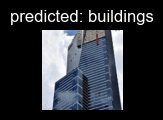

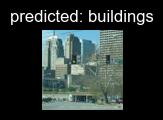

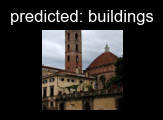

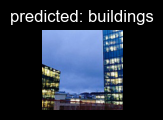

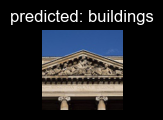

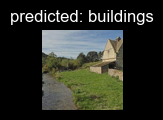

In [6]:
model = SNNModel(dataset_path, **best_params)
model.train()
model.visualize()

## Виводимо якість моделі за метрикою **Macro F1**

In [7]:
score = model.accuracy
print(f"Якість моделі (macro F1): {score:.4f}")

Якість моделі (macro F1): 0.9336


## Виводимо **Confusion Matrix**

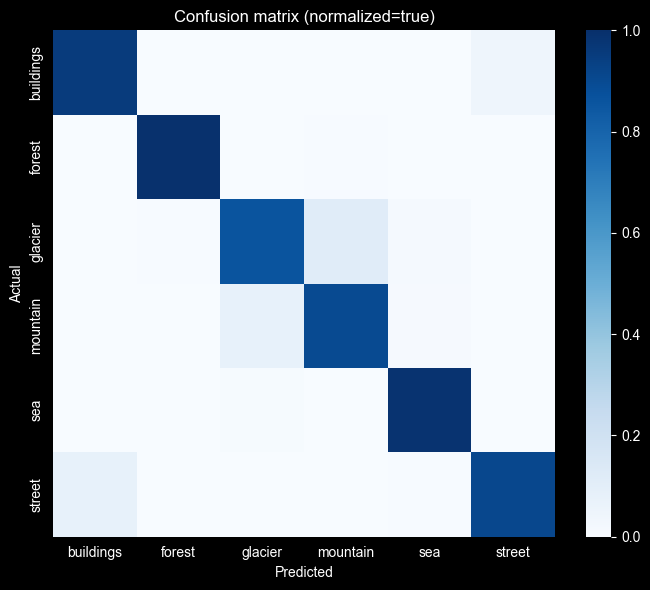

In [8]:
model.show_confusion_matrix()

З наведеної **Confusion Matrix** бачимо, що наша модель найбільше плутає експерименти, що приналежать до класу *вулиця* з класом *будівля*, а *рівнини* з *горами*. Вочевидь, що вулиця містить будівлі і тому така невідповідність має чітке логічне пояснення. Також як гори, так і рівнини мають щонайменше траву.

## Summary моделі та висновки

In [9]:
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

y_true, y_pred = model.get_pred_values()

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Macro F1:", f1_score(y_true, y_pred, average="macro"))
print(classification_report(y_true, y_pred, target_names=model.class_names))

Accuracy: 0.9323333333333333
Macro F1: 0.9336418423895593
              precision    recall  f1-score   support

   buildings       0.90      0.95      0.93       437
      forest       0.99      0.99      0.99       474
     glacier       0.91      0.86      0.88       553
    mountain       0.88      0.90      0.89       525
         sea       0.96      0.99      0.97       510
      street       0.96      0.91      0.93       501

    accuracy                           0.93      3000
   macro avg       0.93      0.93      0.93      3000
weighted avg       0.93      0.93      0.93      3000



Як бачимо, що **Accuracy**, що **Macro F1** більш чи менш рівні, що означає, що математично, та к і в загальному якість моделі однакова. 93% означає, що модель достатньо добра і не перенавчена (така підозра завжди виникає, коли модель показує акуратність 98 - 100%). айточніше модель визначає обʼєкти класу *ліс* (99% точності). Це повʼязано із тим, що важко знайти щ якийсь клас, який міститиме суцільні ряди дерев, як то є у лісах. Найнижча точність (88%) є у визначенні гір. Як ми вже бачили з **Confusion Matrix**, модель часто плутає гори і рівнини. Можливо, для покращення визчння цих обґєктів ми повинні збільшити штучно зговані з існуючих як гори, як і будинки з вулицями.
Протягом експериментів я помітив, що автоматизація підбору гіперпараметрів покращує модель (в моєму випадку це було близько 1%) але не є панацеєю. Потрібно також покращувати також і архітектуру самої мережі, базуючись на експериментах з даними.